## Importando as bibliotecas e configurando os gráficos

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal

# Configurações visuais dos gráficos
plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['axes.grid'] = True

# Filtragem de Senoides

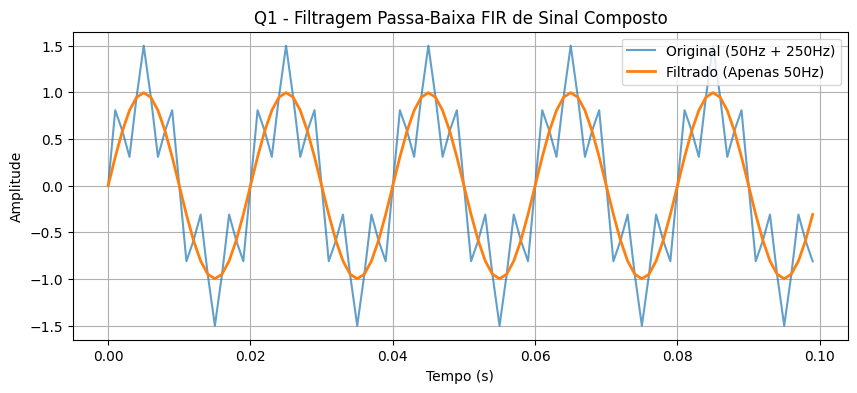

In [2]:
fs = 1000  # Frequência de amostragem
t = np.arange(0, 1, 1/fs)

# Sinal composto: 50 Hz e 250 Hz
f1, f2 = 50, 250
sinal_original = np.sin(2 * np.pi * f1 * t) + 0.5 * np.sin(2 * np.pi * f2 * t)

# Projeto do Filtro FIR Passa-baixa (fc = 100 Hz)
fc = 100
numtaps = 51
b_fir = signal.firwin(numtaps, fc, fs=fs)
sinal_filtrado_q1 = signal.filtfilt(b_fir, 1, sinal_original)

plt.plot(t[:100], sinal_original[:100], label='Original (50Hz + 250Hz)', alpha=0.7)
plt.plot(t[:100], sinal_filtrado_q1[:100], label='Filtrado (Apenas 50Hz)', linewidth=2)
plt.title("Q1 - Filtragem Passa-Baixa FIR de Sinal Composto")
plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.show()

#  Sinal com Ruído Branco (FIR e IIR)

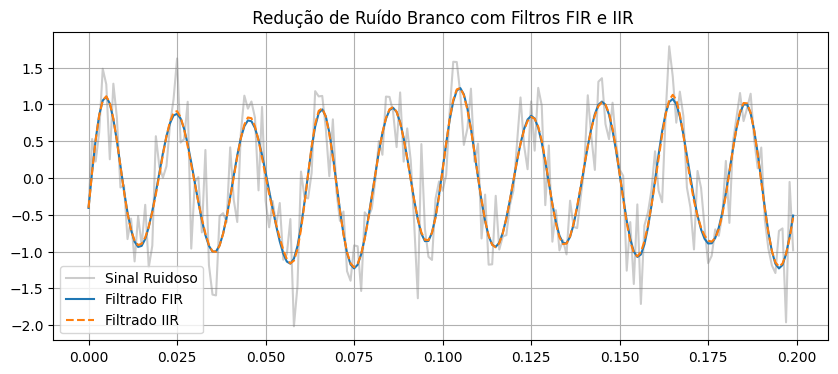

In [5]:
# Geração do ruído
ruido = np.random.normal(0, 0.5, len(t))
sinal_ruidoso = np.sin(2 * np.pi * f1 * t) + ruido

# Filtro FIR para ruído
sinal_filtrado_fir = signal.filtfilt(b_fir, 1, sinal_ruidoso)

# Filtro IIR Butterworth para ruído (mesma fc)
ordem = 4
b_iir, a_iir = signal.butter(ordem, fc, btype='low', fs=fs)
sinal_filtrado_iir = signal.filtfilt(b_iir, a_iir, sinal_ruidoso)

plt.plot(t[:200], sinal_ruidoso[:200], label='Sinal Ruidoso', alpha=0.4, color='gray')
plt.plot(t[:200], sinal_filtrado_fir[:200], label='Filtrado FIR', linewidth=1.5)
plt.plot(t[:200], sinal_filtrado_iir[:200], label='Filtrado IIR', linewidth=1.5, linestyle='--')
plt.title(" Redução de Ruído Branco com Filtros FIR e IIR")
plt.legend()
plt.show()

## Resposta em Frequência e Fase

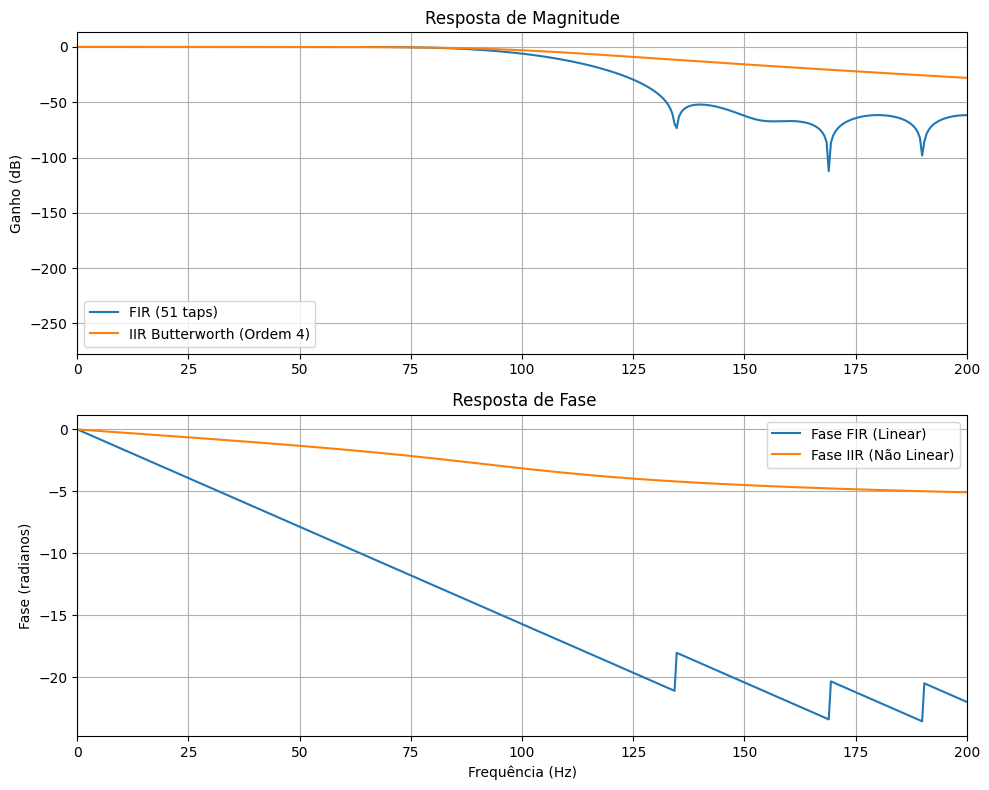

In [7]:
w_fir, h_fir = signal.freqz(b_fir, 1, worN=1024, fs=fs)
w_iir, h_iir = signal.freqz(b_iir, a_iir, worN=1024, fs=fs)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# Magnitude
ax1.plot(w_fir, 20 * np.log10(abs(h_fir)), label='FIR (51 taps)')
ax1.plot(w_iir, 20 * np.log10(abs(h_iir)), label=f'IIR Butterworth (Ordem {ordem})')
ax1.set_title("Resposta de Magnitude")
ax1.set_ylabel("Ganho (dB)")
ax1.set_xlim(0, 200)
ax1.legend()

# Fase (Desdobrada / Unwrapped)
fase_fir = np.unwrap(np.angle(h_fir))
fase_iir = np.unwrap(np.angle(h_iir))

ax2.plot(w_fir, fase_fir, label='Fase FIR (Linear)')
ax2.plot(w_iir, fase_iir, label='Fase IIR (Não Linear)')
ax2.set_title(" Resposta de Fase")
ax2.set_xlabel("Frequência (Hz)")
ax2.set_ylabel("Fase (radianos)")
ax2.set_xlim(0, 200)
ax2.legend()
plt.tight_layout()
plt.show()

## Polos e Zeros do Filtro IIR

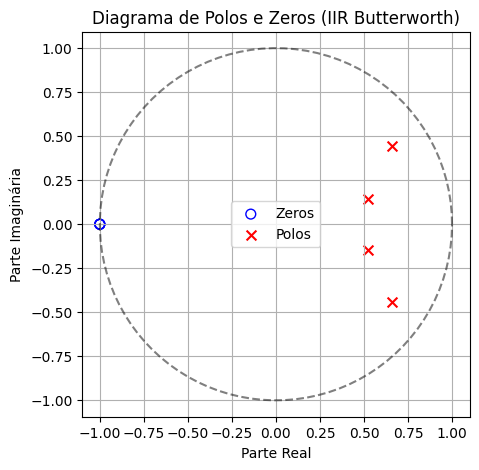

In [9]:
z, p, k = signal.tf2zpk(b_iir, a_iir)

plt.figure(figsize=(5, 5))
plt.scatter(np.real(z), np.imag(z), s=50, marker='o', facecolors='none', edgecolors='b', label='Zeros')
plt.scatter(np.real(p), np.imag(p), s=50, marker='x', color='r', label='Polos')

# Círculo Unitário
theta = np.linspace(0, 2*np.pi, 100)
plt.plot(np.cos(theta), np.sin(theta), 'k--', alpha=0.5)

plt.title("Diagrama de Polos e Zeros (IIR Butterworth)")
plt.xlabel("Parte Real")
plt.ylabel("Parte Imaginária")
plt.axis('equal')
plt.legend()
plt.show()

## Resposta ao Impulso

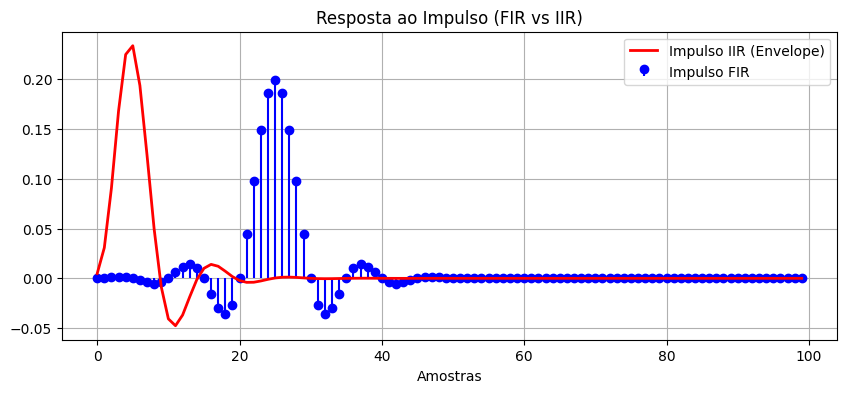

In [10]:
impulso = np.zeros(100)
impulso[0] = 1.0

# Respostas
h_t_fir = signal.lfilter(b_fir, 1, impulso)
h_t_iir = signal.lfilter(b_iir, a_iir, impulso)

plt.stem(h_t_fir, basefmt=" ", linefmt='b-', markerfmt='bo', label='Impulso FIR')
plt.plot(h_t_iir, 'r-', label='Impulso IIR (Envelope)', linewidth=2)
plt.title("Resposta ao Impulso (FIR vs IIR)")
plt.xlabel("Amostras")
plt.legend()
plt.show()

## Filtro Passa-Faixa

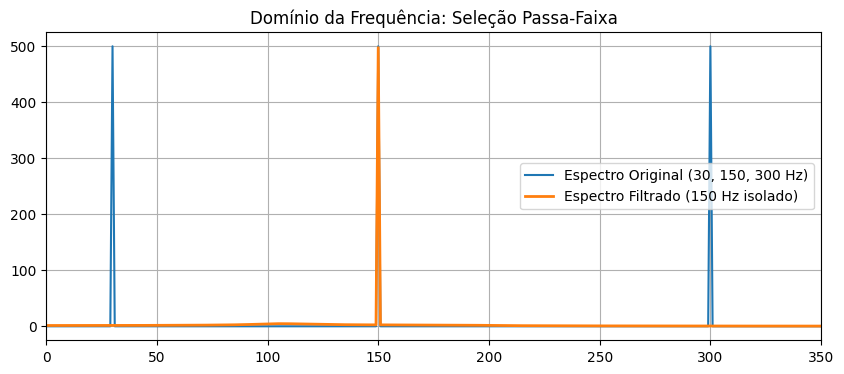

In [11]:
sinal_3 = np.sin(2*np.pi*30*t) + np.sin(2*np.pi*150*t) + np.sin(2*np.pi*300*t)

# Filtro Passa-Faixa (mantendo apenas 150Hz)
b_bandpass = signal.firwin(101, [100, 200], pass_zero=False, fs=fs)
sinal_isolado = signal.filtfilt(b_bandpass, 1, sinal_3)

# FFT para visualização
fft_orig = np.abs(np.fft.rfft(sinal_3))
fft_filt = np.abs(np.fft.rfft(sinal_isolado))
freqs = np.fft.rfftfreq(len(sinal_3), 1/fs)

plt.plot(freqs, fft_orig, label='Espectro Original (30, 150, 300 Hz)')
plt.plot(freqs, fft_filt, label='Espectro Filtrado (150 Hz isolado)', linewidth=2)
plt.title("Domínio da Frequência: Seleção Passa-Faixa")
plt.xlim(0, 350)
plt.legend()
plt.show()

## Atraso de Grupo

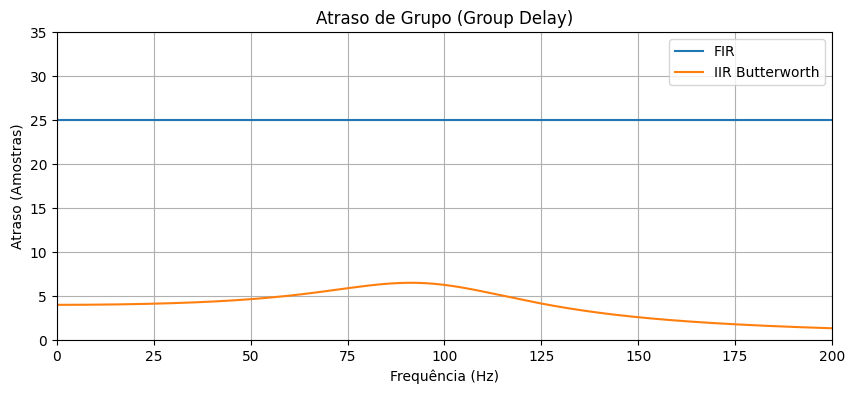

In [12]:
w, gd_fir = signal.group_delay((b_fir, 1), w=1024, fs=fs)
w, gd_iir = signal.group_delay((b_iir, a_iir), w=1024, fs=fs)

plt.plot(w, gd_fir, label='FIR')
plt.plot(w, gd_iir, label='IIR Butterworth')
plt.title("Atraso de Grupo (Group Delay)")
plt.ylabel("Atraso (Amostras)")
plt.xlabel("Frequência (Hz)")
plt.xlim(0, 200)
plt.ylim(0, max(np.max(gd_fir), np.max(gd_iir)) + 10)
plt.legend()
plt.show()

## Problema Norteador: Monitoramento Agrícola (Sensores)

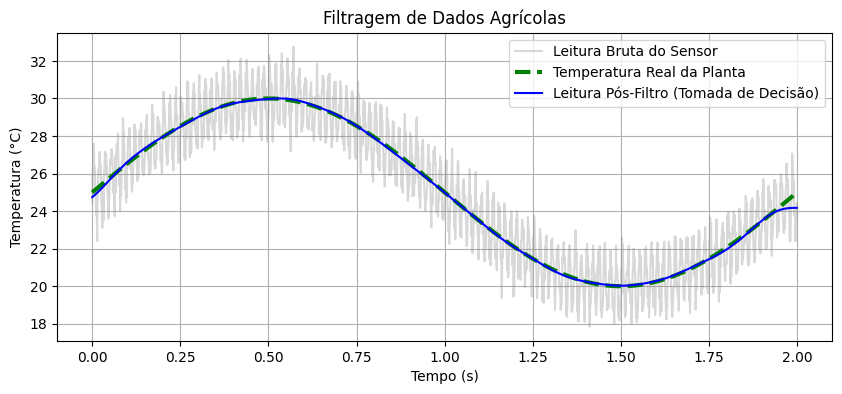

In [13]:
# Simulação do sensor de temperatura em campo:
# Variação real lenta (baixa frequência) + Ruído de rede (60 Hz) + Ruído térmico (branco)
t_sensor = np.arange(0, 2, 1/fs)
temp_real = 25 + 5 * np.sin(2 * np.pi * 0.5 * t_sensor) # Variação de temperatura 0.5Hz
ruido_rede = 1.5 * np.sin(2 * np.pi * 60 * t_sensor) # Interferência 60 Hz
ruido_termico = np.random.normal(0, 0.5, len(t_sensor))

leitura_sensor = temp_real + ruido_rede + ruido_termico

# O objetivo para tomada de decisão (ex: acionar irrigação) é isolar a `temp_real`.
# Filtro IIR passa-baixa agressivo (fc = 5 Hz) para remover os 60Hz e ruído de alta frequência
b_sensor, a_sensor = signal.butter(3, 5, btype='low', fs=fs)
leitura_tratada = signal.filtfilt(b_sensor, a_sensor, leitura_sensor)

plt.plot(t_sensor, leitura_sensor, label='Leitura Bruta do Sensor', alpha=0.3, color='gray')
plt.plot(t_sensor, temp_real, label='Temperatura Real da Planta', linewidth=3, linestyle='--', color='green')
plt.plot(t_sensor, leitura_tratada, label='Leitura Pós-Filtro (Tomada de Decisão)', color='blue')
plt.title("Filtragem de Dados Agrícolas")
plt.xlabel("Tempo (s)")
plt.ylabel("Temperatura (°C)")
plt.legend()
plt.show()